In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [2]:
df=pd.read_csv("data.csv")

In [3]:
def eda():
    print(f"shape:{df.shape}\n")
    print(f"top 5 rows:\n{df.head(5)}\nbottom 5 rows:\n{df.tail(5)}\n")
    print(f"data-types:{df.dtypes}\n")
    print(f"missing values:{df.isna().sum()}")
    print(f"statistics:{df.describe()}")
    print(f"duplicate values:{df.duplicated()}")
    for i in df.select_dtypes(include="object").columns.tolist():
        print(f"unique values:\n{df[i].value_counts()}\n")
eda()


shape:(1124, 9)

top 5 rows:
     Area_SqFt  Rooms  Build_Year Location       Street_Type      Furnishing  \
0  2473.192784    4.0        1992   Jaipur  Residential Lane       Furnished   
1  2353.472711    4.0        2006   Indore       Corner Plot     Unfurnished   
2  2212.222005    3.0        2012   Jaipur    Highway Facing  Semi-Furnished   
3  2823.886596    6.0        1993  Lucknow         Main Road     Unfurnished   
4  1869.648721    5.0        2012   Jaipur       Corner Plot  Semi-Furnished   

  Property_Type Has_Pool     Price  
0     Apartment       No  568486.0  
1     Apartment      Yes  577214.0  
2        Duplex       No  581300.0  
3         Villa      Yes  794614.0  
4     Apartment       No  493086.0  
bottom 5 rows:
        Area_SqFt  Rooms  Build_Year   Location       Street_Type  \
1119  2461.048417    7.0        1988      Noida       Corner Plot   
1120  3558.174078    7.0        1989     Kanpur    Highway Facing   
1121  2179.880978    4.0        2011  Prayagra

distribution analysis of price


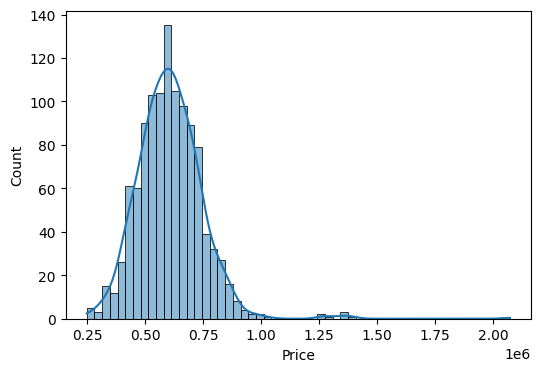

correlation analysis of price


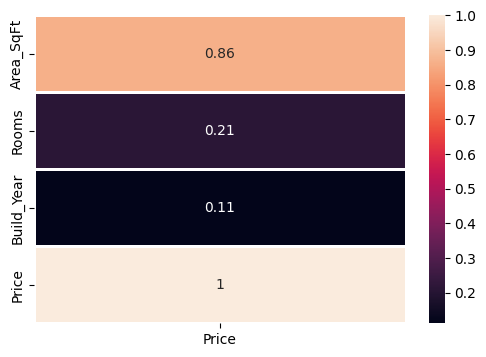

Detect Outliers


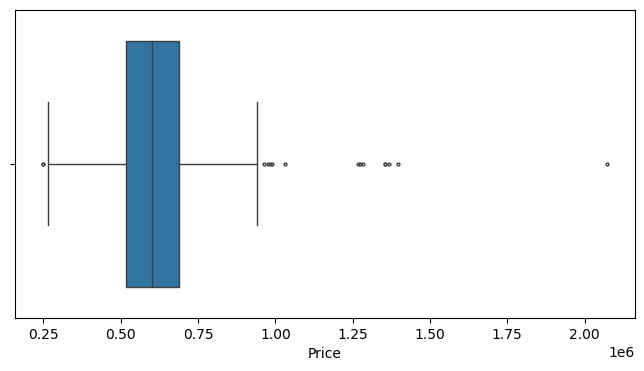

In [4]:
def visualization():
    print("distribution analysis of price")
    plt.figure(figsize=(6,4))
    sns.histplot(data=df,x="Price",kde=True)
    plt.show()
    print("correlation analysis of price")
    plt.figure(figsize=(6,4))
    corr=df.corr(numeric_only=True)[["Price"]]
    sns.heatmap(corr,annot=True,linewidths=2.0,linecolor="White")
    plt.show()
    print("Detect Outliers")
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df,x="Price",fliersize=2)
    plt.show()
visualization()

In [5]:
def data_cleaning():
    df.drop_duplicates()
    for j in df.select_dtypes(include="number").columns.tolist():
        df[j]=df[j].fillna(df[j].mean())
    for k in df.select_dtypes(include="object").columns.tolist():
        df[k]=df[k].fillna("Unknown")
    print(df.isna().sum())
data_cleaning()

Area_SqFt        0
Rooms            0
Build_Year       0
Location         0
Street_Type      0
Furnishing       0
Property_Type    0
Has_Pool         0
Price            0
dtype: int64


In [6]:
def data_preprocessing():
    global X_train, X_test, y_train, y_test
    X = df.drop("Price", axis=1)
    y=df.Price
    X=pd.get_dummies(X,drop_first=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    minmax=MinMaxScaler()
    X_train=minmax.fit_transform(X_train)
    X_test=minmax.transform(X_test)
data_preprocessing()


In [7]:
def model_making():
    model=LinearRegression()
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    return y_pred
model_making()


array([ 688795.54638588,  614831.36919235,  538380.53039301,
        552130.67208891,  584230.26604771,  430273.1924235 ,
        695548.21513906,  551492.29736434,  591754.79472851,
        695234.60457321,  676694.52206205,  722816.95697368,
        453307.78098725,  801487.99669991,  646753.07502674,
        454336.68518452,  579863.86499735,  764784.63138321,
        554052.66895007,  695271.72166755,  704445.85230275,
        595455.13294317,  711516.37228997,  502323.71344459,
        644224.24254056,  629605.31464098,  699497.41856628,
        528541.46685352,  341951.77406378,  589609.90526085,
        508980.54992239,  660190.53821928,  601666.65357859,
        641471.74547909,  530658.33604245,  573438.57003457,
        397507.51720661,  422635.25405743,  420450.90946649,
        699215.88590261,  634552.2576927 ,  655596.43791693,
        742505.07471759,  550468.21080994,  532768.35405692,
        611539.6685025 ,  658404.47537756,  420380.60533492,
        644902.40782957,

In [8]:
def evaluation():
    y_pred=model_making()
    print(f"r2 square score:{r2_score(y_test,y_pred)}")
evaluation()

r2 square score:0.944737056362834
